# Quantum Noise Pipeline — Results Analysis

**Hardware:** ibm_fez (156-qubit IBM Heron processor)  
**Experiments:** T1/T2 coherence, readout error, compilation benchmarks  
**Compilers:** Qiskit (optimization level 3) vs Superstaq (Infleqtion)

This notebook reads directly from the pipeline's SQLite database — as new hardware runs accumulate, re-run all cells to see updated results.

In [3]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from sqlalchemy import create_engine, text
from pathlib import Path

# ── Style config (matches lachlan.site: clean, minimal, muted blues) ──
COLORS = {
    "bg": "#ffffff",
    "text": "#1a1a2e",
    "grid": "#e8e8e8",
    "qiskit": "#4a90d9",      # muted blue
    "superstaq": "#e8734a",   # warm accent
    "qubit_0": "#4a90d9",
    "qubit_1": "#2ecc71",
    "qubit_2": "#e8734a",
    "qubit_3": "#9b59b6",
    "drift_fill": "rgba(74, 144, 217, 0.1)",
}

LAYOUT_DEFAULTS = dict(
    font=dict(family="Inter, Helvetica, Arial, sans-serif", color=COLORS["text"], size=13),
    paper_bgcolor=COLORS["bg"],
    plot_bgcolor=COLORS["bg"],
    margin=dict(l=60, r=30, t=50, b=50),
    xaxis=dict(gridcolor=COLORS["grid"], zeroline=False),
    yaxis=dict(gridcolor=COLORS["grid"], zeroline=False),
)

def style(fig: go.Figure) -> go.Figure:
    """Apply consistent styling to a plotly figure."""
    fig.update_layout(**LAYOUT_DEFAULTS)
    return fig

# ── Database connection ──
DB_PATH = Path("..") / "quantum_noise_pipeline.db"
if not DB_PATH.exists():
    DB_PATH = Path("quantum_noise_pipeline.db")
engine = create_engine(f"sqlite:///{DB_PATH}")

print(f"Connected to: {DB_PATH.resolve()}")
print(f"Tables: {engine.table_names()}" if hasattr(engine, 'table_names') else "")

Connected to: /Users/lachlanhaydon/Desktop/Projects/QNoise/quantum_noise_pipeline.db



In [4]:
# ── Load all data from database ──
t1_df = pd.read_sql("SELECT * FROM t1_results ORDER BY timestamp", engine)
t2_df = pd.read_sql("SELECT * FROM t2_results ORDER BY timestamp", engine)
readout_df = pd.read_sql("SELECT * FROM readout_error_results ORDER BY timestamp", engine)
benchmark_df = pd.read_sql("SELECT * FROM compilation_benchmarks ORDER BY timestamp", engine)
jobs_df = pd.read_sql("SELECT * FROM job_records ORDER BY submitted_at", engine)

print(f"T1 results:      {len(t1_df)} rows")
print(f"T2 results:      {len(t2_df)} rows")
print(f"Readout results: {len(readout_df)} rows")
print(f"Benchmarks:      {len(benchmark_df)} rows")
print(f"Jobs tracked:    {len(jobs_df)} rows")

T1 results:      6 rows
T2 results:      6 rows
Readout results: 6 rows
Benchmarks:      8 rows
Jobs tracked:    4 rows


## 1. T1 & T2 Temporal Drift

Qubit coherence properties are not static — they drift on the timescale of hours due to TLS fluctuators, flux noise, and recalibration cycles. The plot below shows every measurement over time, revealing which qubits are stable and which are volatile.

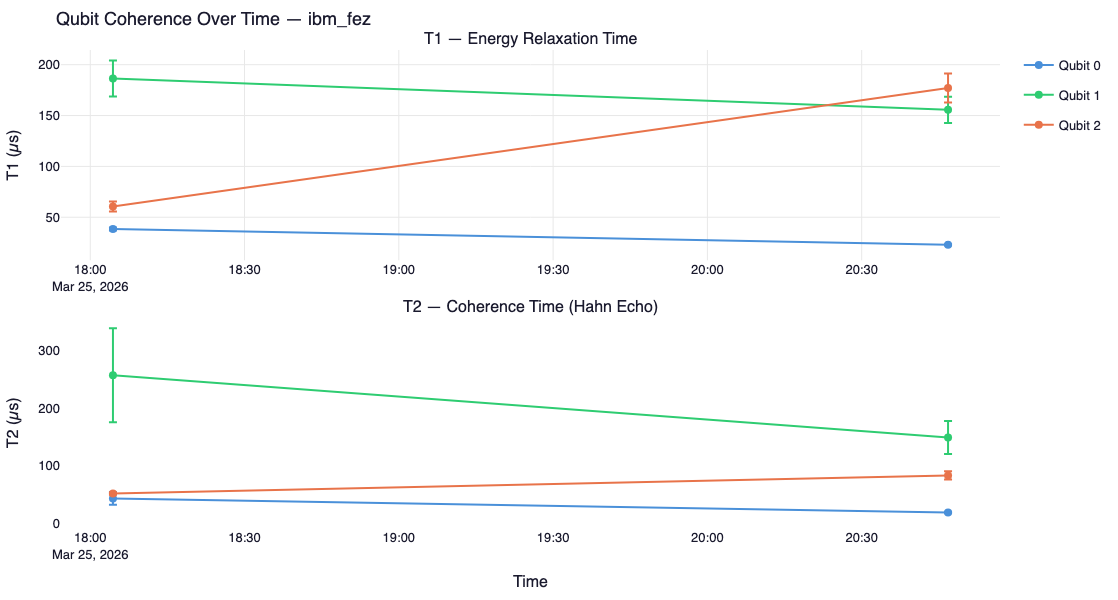

In [13]:
# ── T1 and T2 over time (one trace per qubit, expandable) ──
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=("T1 — Energy Relaxation Time", "T2 — Coherence Time (Hahn Echo)"),
    vertical_spacing=0.12,
)

t1_df["timestamp"] = pd.to_datetime(t1_df["timestamp"])
t2_df["timestamp"] = pd.to_datetime(t2_df["timestamp"])

for qubit in sorted(t1_df["qubit"].unique()):
    color = COLORS.get(f"qubit_{qubit}", "#888888")
    qdata = t1_df[t1_df["qubit"] == qubit]
    fig.add_trace(go.Scatter(
        x=qdata["timestamp"], y=qdata["t1_us"],
        error_y=dict(type="data", array=qdata["t1_stderr"].fillna(0), visible=True),
        mode="lines+markers",
        name=f"Qubit {qubit}",
        marker=dict(size=8, color=color),
        line=dict(color=color, width=2),
        legendgroup=f"q{qubit}",
    ), row=1, col=1)

for qubit in sorted(t2_df["qubit"].unique()):
    color = COLORS.get(f"qubit_{qubit}", "#888888")
    qdata = t2_df[t2_df["qubit"] == qubit]
    fig.add_trace(go.Scatter(
        x=qdata["timestamp"], y=qdata["t2_us"],
        error_y=dict(type="data", array=qdata["t2_stderr"].fillna(0), visible=True),
        mode="lines+markers",
        name=f"Qubit {qubit}",
        marker=dict(size=8, color=color),
        line=dict(color=color, width=2),
        legendgroup=f"q{qubit}",
        showlegend=False,
    ), row=2, col=1)

fig.update_yaxes(title_text="T1 (µs)", row=1, col=1)
fig.update_yaxes(title_text="T2 (µs)", row=2, col=1)
fig.update_xaxes(title_text="Time", row=2, col=1)

style(fig)
fig.update_layout(height=600, title_text="Qubit Coherence Over Time — ibm_fez")
fig.show()

## 2. T1 vs T2 Relationship

Physics constrains T2 ≤ 2×T1. Points near the diagonal indicate energy relaxation dominates decoherence. Points well below suggest additional dephasing noise. Each point is one measurement of one qubit.

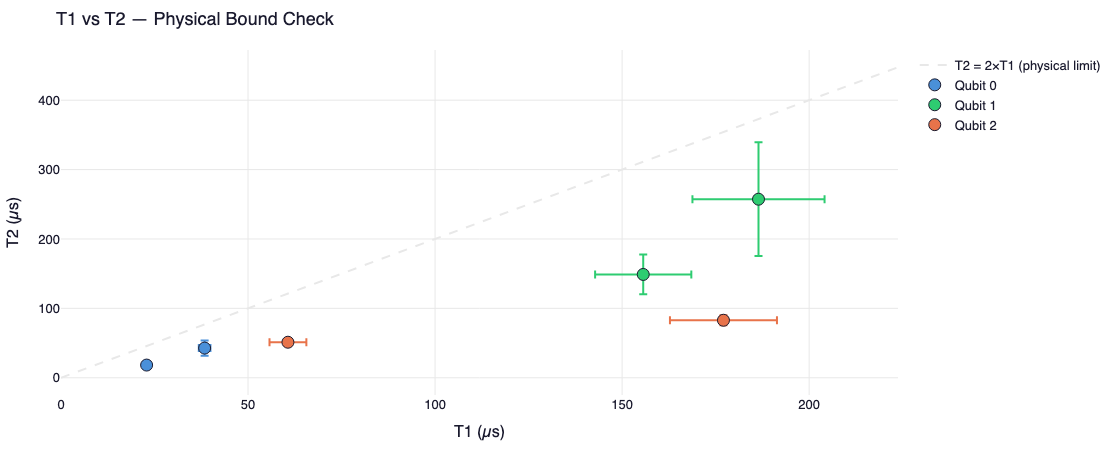

In [14]:
# ── T1 vs T2 scatter with physical bound line ──
# Merge T1 and T2 by qubit + closest timestamp
t1_merge = t1_df[["qubit", "timestamp", "t1_us", "t1_stderr"]].copy()
t2_merge = t2_df[["qubit", "timestamp", "t2_us", "t2_stderr"]].copy()

# Round timestamps to nearest minute for merge
t1_merge["ts_round"] = t1_merge["timestamp"].dt.round("1min")
t2_merge["ts_round"] = t2_merge["timestamp"].dt.round("1min")

coherence_df = pd.merge(t1_merge, t2_merge, on=["qubit", "ts_round"], suffixes=("_t1", "_t2"))

fig = go.Figure()

# T2 = 2*T1 physical bound
max_t1 = coherence_df["t1_us"].max() * 1.2 if len(coherence_df) > 0 else 300
fig.add_trace(go.Scatter(
    x=[0, max_t1], y=[0, 2 * max_t1],
    mode="lines", name="T2 = 2×T1 (physical limit)",
    line=dict(color=COLORS["grid"], dash="dash", width=2),
))

for qubit in sorted(coherence_df["qubit"].unique()):
    color = COLORS.get(f"qubit_{qubit}", "#888888")
    qdata = coherence_df[coherence_df["qubit"] == qubit]
    fig.add_trace(go.Scatter(
        x=qdata["t1_us"], y=qdata["t2_us"],
        error_x=dict(type="data", array=qdata["t1_stderr"].fillna(0), visible=True),
        error_y=dict(type="data", array=qdata["t2_stderr"].fillna(0), visible=True),
        mode="markers",
        name=f"Qubit {qubit}",
        marker=dict(size=12, color=color, line=dict(width=1, color=COLORS["text"])),
    ))

style(fig)
fig.update_layout(
    title="T1 vs T2 — Physical Bound Check",
    xaxis_title="T1 (µs)",
    yaxis_title="T2 (µs)",
    height=450,
    width=600,
)
fig.show()

## 3. Readout Error by Qubit

Readout assignment errors are asymmetric: P(measure 1 | prepared 0) is typically much lower than P(measure 0 | prepared 1). This is because the |1⟩ state can decay to |0⟩ *during* the measurement process itself (a T1 effect). The most recent measurement per qubit is shown.

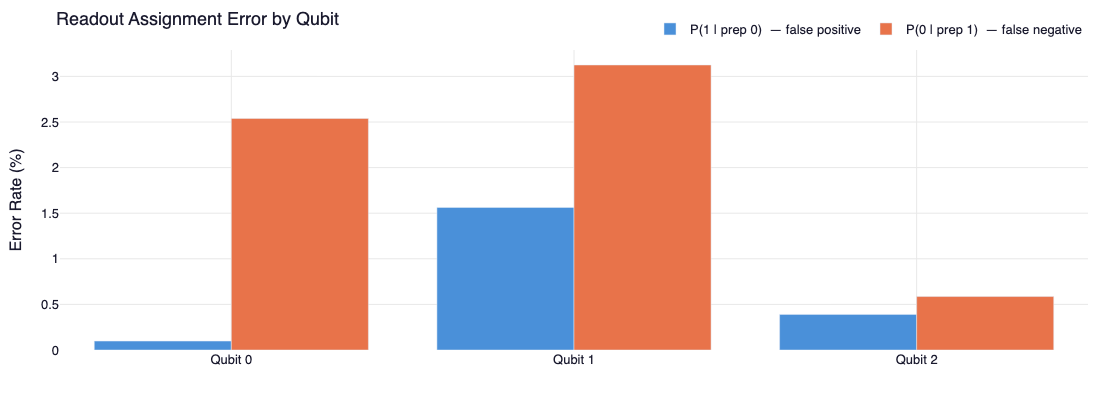

In [15]:
# ── Readout error grouped bar chart ──
readout_df["timestamp"] = pd.to_datetime(readout_df["timestamp"])

# Use all measurements (they'll stack as more data comes in)
latest = readout_df.sort_values("timestamp").groupby("qubit").last().reset_index()

fig = go.Figure()

fig.add_trace(go.Bar(
    x=[f"Qubit {q}" for q in latest["qubit"]],
    y=latest["error_rate_0to1"] * 100,
    name="P(1 | prep 0)  — false positive",
    marker_color=COLORS["qiskit"],
))

fig.add_trace(go.Bar(
    x=[f"Qubit {q}" for q in latest["qubit"]],
    y=latest["error_rate_1to0"] * 100,
    name="P(0 | prep 1)  — false negative",
    marker_color=COLORS["superstaq"],
))

style(fig)
fig.update_layout(
    title="Readout Assignment Error by Qubit",
    yaxis_title="Error Rate (%)",
    barmode="group",
    height=400,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1),
)
fig.show()

## 4. Compilation Benchmark — Qiskit vs Superstaq

The headline comparison: identical circuits compiled through two different optimizers, then executed on the same hardware. The key insight is that **2-qubit gate count predicts fidelity better than circuit depth.**

/var/folders/ld/z0tpdb3917l8g8gzqsc8h5680000gn/T/ipykernel_19682/3371888347.py:16: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.

/var/folders/ld/z0tpdb3917l8g8gzqsc8h5680000gn/T/ipykernel_19682/3371888347.py:16: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



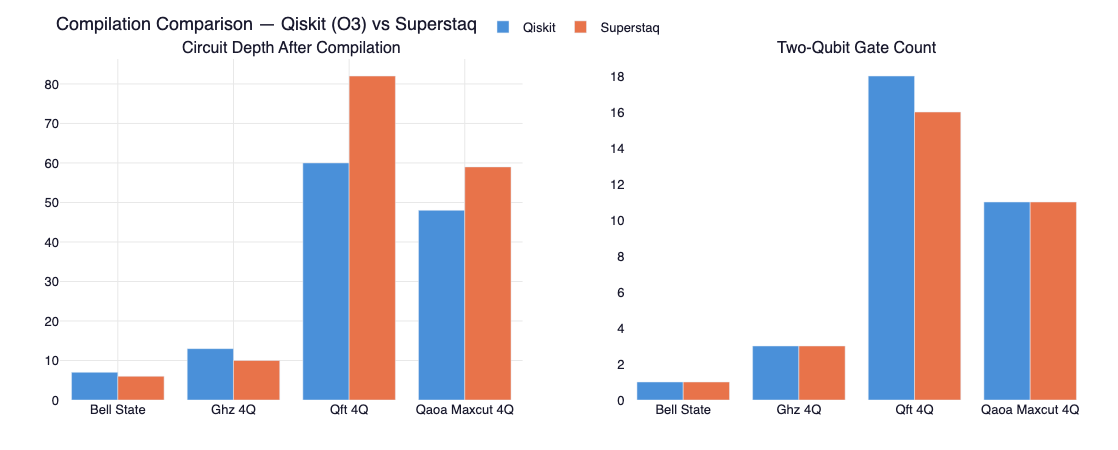

In [16]:
# ── Compilation metrics: depth and 2Q gate comparison ──
if len(benchmark_df) > 0:
    # Pivot for side-by-side comparison
    circuits_order = ["bell_state", "ghz_4q", "qft_4q", "qaoa_maxcut_4q"]
    bm = benchmark_df[benchmark_df["circuit_name"].isin(circuits_order)].copy()
    
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("Circuit Depth After Compilation", "Two-Qubit Gate Count"),
    )
    
    for compiler, color in [("qiskit", COLORS["qiskit"]), ("superstaq", COLORS["superstaq"])]:
        cdata = bm[bm["compiler"] == compiler].copy()
        # Ensure consistent ordering
        cdata["circuit_name"] = pd.Categorical(cdata["circuit_name"], categories=circuits_order, ordered=True)
        cdata = cdata.sort_values("circuit_name").groupby("circuit_name").last().reset_index()
        
        labels = [c.replace("_", " ").title() for c in cdata["circuit_name"]]
        
        fig.add_trace(go.Bar(
            x=labels, y=cdata["depth_after"],
            name=compiler.capitalize(),
            marker_color=color,
            legendgroup=compiler,
        ), row=1, col=1)
        
        fig.add_trace(go.Bar(
            x=labels, y=cdata["cx_count"],
            name=compiler.capitalize(),
            marker_color=color,
            legendgroup=compiler,
            showlegend=False,
        ), row=1, col=2)
    
    style(fig)
    fig.update_layout(
        title="Compilation Comparison — Qiskit (O3) vs Superstaq",
        barmode="group",
        height=450,
        legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="center", x=0.5),
    )
    fig.show()
else:
    print("No benchmark data yet. Run scripts/run_compilation_benchmark.py first.")

In [12]:
# ── Hardware fidelity comparison (the money chart) ──
if len(benchmark_df) > 0:
    bm_fid = bm[bm["fidelity"].notna()].copy()
    
    if len(bm_fid) > 0:
        fig = go.Figure()
        
        for compiler, color in [("qiskit", COLORS["qiskit"]), ("superstaq", COLORS["superstaq"])]:
            cdata = bm_fid[bm_fid["compiler"] == compiler].copy()
            cdata["circuit_name"] = pd.Categorical(cdata["circuit_name"], categories=circuits_order, ordered=True)
            cdata = cdata.sort_values("circuit_name").groupby("circuit_name").last().reset_index()
            
            labels = [c.replace("_", " ").title() for c in cdata["circuit_name"]]
            
            fig.add_trace(go.Bar(
                x=labels, y=cdata["fidelity"],
                name=compiler.capitalize(),
                marker_color=color,
                text=[f"{f:.4f}" for f in cdata["fidelity"]],
                textposition="outside",
                textfont=dict(size=12),
            ))
        
        style(fig)
        fig.update_layout(
            title="Hardware Fidelity — Qiskit vs Superstaq on ibm_fez",
            yaxis_title="Hellinger Fidelity",
            yaxis_range=[0.9, 1.005],
            barmode="group",
            height=450,
            legend=dict(orientation="h", yanchor="bottom", y=1.05, xanchor="center", x=0.5),
        )
        fig.show()
    else:
        print("No fidelity data available yet.")
else:
    print("No benchmark data yet.")

NameError: name 'bm' is not defined

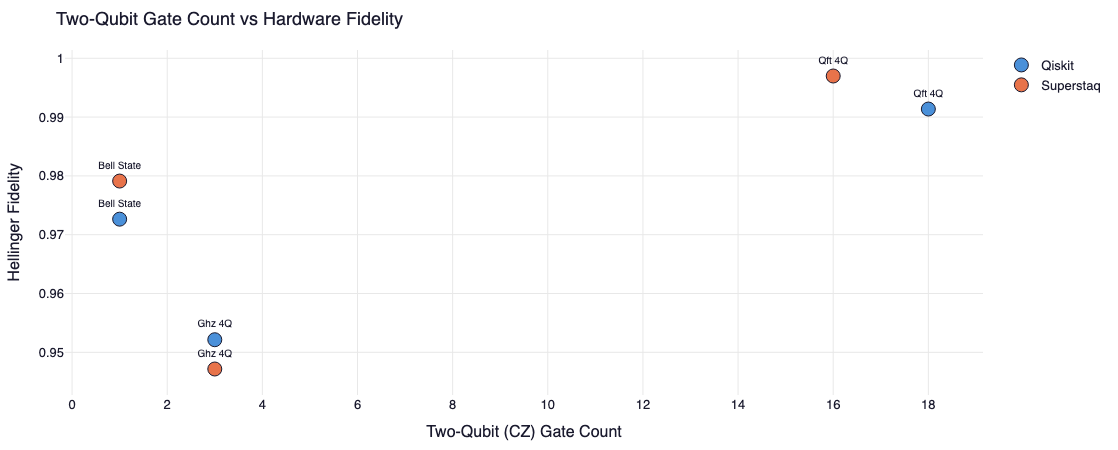

In [17]:
# ── 2Q gate count vs fidelity scatter ──
if len(benchmark_df) > 0:
    bm_scatter = bm[bm["fidelity"].notna()].copy()
    
    if len(bm_scatter) > 0:
        fig = go.Figure()
        
        for compiler, color in [("qiskit", COLORS["qiskit"]), ("superstaq", COLORS["superstaq"])]:
            cdata = bm_scatter[bm_scatter["compiler"] == compiler]
            fig.add_trace(go.Scatter(
                x=cdata["cx_count"], y=cdata["fidelity"],
                mode="markers+text",
                name=compiler.capitalize(),
                marker=dict(size=14, color=color, line=dict(width=1, color=COLORS["text"])),
                text=cdata["circuit_name"].str.replace("_", " ").str.title(),
                textposition="top center",
                textfont=dict(size=10),
            ))
        
        style(fig)
        fig.update_layout(
            title="Two-Qubit Gate Count vs Hardware Fidelity",
            xaxis_title="Two-Qubit (CZ) Gate Count",
            yaxis_title="Hellinger Fidelity",
            height=450,
            width=650,
        )
        fig.show()
    else:
        print("Need fidelity data — run the compilation benchmark on hardware first.")
else:
    print("No benchmark data yet.")

## 6. Summary Statistics

Auto-generated summary of all data in the database. This table grows as more runs are added.

In [18]:
# ── Summary table ──
print("=" * 60)
print("  QUANTUM NOISE PIPELINE — DATA SUMMARY")
print("=" * 60)

print(f"\n  Hardware runs:       {len(jobs_df)}")
print(f"  Date range:          {jobs_df['submitted_at'].min()[:10]} → {jobs_df['submitted_at'].max()[:10]}")
print(f"  Qubits measured:     {sorted(t1_df['qubit'].unique().tolist())}")

print(f"\n  T1 measurements:     {len(t1_df)}")
if len(t1_df) > 0:
    for q in sorted(t1_df["qubit"].unique()):
        qd = t1_df[t1_df["qubit"] == q]
        print(f"    Qubit {q}: T1 = {qd['t1_us'].mean():.1f} ± {qd['t1_us'].std():.1f} µs  (n={len(qd)}, range={qd['t1_us'].min():.1f}–{qd['t1_us'].max():.1f})")

print(f"\n  T2 measurements:     {len(t2_df)}")
if len(t2_df) > 0:
    for q in sorted(t2_df["qubit"].unique()):
        qd = t2_df[t2_df["qubit"] == q]
        print(f"    Qubit {q}: T2 = {qd['t2_us'].mean():.1f} ± {qd['t2_us'].std():.1f} µs  (n={len(qd)}, range={qd['t2_us'].min():.1f}–{qd['t2_us'].max():.1f})")

print(f"\n  Benchmark circuits:  {len(benchmark_df)}")
if len(benchmark_df) > 0:
    for circ in benchmark_df["circuit_name"].unique():
        cd = benchmark_df[benchmark_df["circuit_name"] == circ]
        compilers = ", ".join(cd["compiler"].unique())
        print(f"    {circ}: {compilers}")

print(f"\n  Database: {DB_PATH.resolve()}")
print("=" * 60)

  QUANTUM NOISE PIPELINE — DATA SUMMARY

  Hardware runs:       4
  Date range:          2026-03-25 → 2026-03-25
  Qubits measured:     [0, 1, 2]

  T1 measurements:     6
    Qubit 0: T1 = 30.6 ± 11.0 µs  (n=2, range=22.9–38.4)
    Qubit 1: T1 = 171.0 ± 21.8 µs  (n=2, range=155.6–186.5)
    Qubit 2: T1 = 118.9 ± 82.3 µs  (n=2, range=60.7–177.1)

  T2 measurements:     6
    Qubit 0: T2 = 30.5 ± 17.3 µs  (n=2, range=18.3–42.8)
    Qubit 1: T2 = 203.1 ± 76.7 µs  (n=2, range=148.9–257.3)
    Qubit 2: T2 = 67.0 ± 22.4 µs  (n=2, range=51.2–82.8)

  Benchmark circuits:  8
    bell_state: qiskit, superstaq
    ghz_4q: qiskit, superstaq
    qft_4q: qiskit, superstaq
    qaoa_maxcut_4q: qiskit, superstaq

  Database: /Users/lachlanhaydon/Desktop/Projects/QNoise/quantum_noise_pipeline.db
